# Sociodemographic Determinants of Health Insurance Costs in the United States

**Thibault Fievé. ESLSCA Business School. Supervisor: Marouan Korfed.**

This is an exploratory analysis of 1,338 beneficiaries from the Medical Cost Personal Dataset (Kaggle). The aim is to identify which sociodemographic factors drive medical charge disparities and whether they interact. We fit four models (a baseline, an OLS on log(charges), a Gamma GLM, a Random Forest), then derive a five tier risk segmentation from the model predictions. Modeling choices were informed by the EDA and are reported transparently.

## Setup

Imports, global seed, color palette. The seed is fixed once so the data split, the bootstrap and the Random Forest are reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

seed = 42
np.random.seed(seed)
sns.set_theme(style='darkgrid', palette='deep')
sns.set_context("paper")
palette = {'no': '#5975a4', 'yes': '#cc8963'}

def label_pct(ax):
    """Add percent labels on bars of a countplot with stat='proportion'."""
    for c in ax.containers:
        ax.bar_label(c, labels=[f'{v.get_height():.1%}' for v in c], padding=3)

/home/thibaultfieve/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Data

The dataset has 1,338 observations and 7 variables with no missing values. Three are categorical (sex, smoker, region), three are continuous (age, BMI, charges), one is a count (children).


In [2]:
df = pd.read_csv('../data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


Mean charges $13,270 against median $9,382 signals a strong right skew, which motivates the log transformation in the EDA below.
## Data Quality

Three checks before modeling. No missing values. One exact duplicate (rows 195 and 581) which we drop, leaving n = 1,337. All ranges plausible: BMI from 15.96 to 53.13, age from 18 to 64, charges from $1,122 to $63,770. Smokers make up 20.5% of the sample, the main structural imbalance.


In [5]:
print(f'Missing values: {df.isna().sum().sum()}')
print(f'Duplicates:     {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'After dedup:    n = {len(df)}')
print(f'BMI range:      {df.bmi.min():.2f} to {df.bmi.max():.2f}')
print(f'Age range:      {df.age.min()} to {df.age.max()}')
print(f'Charges range:  ${df.charges.min():,.0f} to ${df.charges.max():,.0f}')
print(f'Smoker share:   {(df.smoker == "yes").mean() * 100:.1f}%')

Missing values: 0
Duplicates:     1
After dedup:    n = 1337
BMI range:      15.96 to 53.13
Age range:      18 to 64
Charges range:  $1,122 to $63,770
Smoker share:   20.5%


## Train and Test Split

We hold out 20% of observations as a test set, stratified by smoker to preserve the 20.5% prevalence. Everything below uses the training set only. The test set is touched once at model comparison.

In [6]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=seed, stratify=df['smoker'])
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)
print(f'Train: n = {len(df_train)}, smoker = {(df_train.smoker == "yes").mean()*100:.1f}%')
print(f'Test:  n = {len(df_test)}, smoker = {(df_test.smoker == "yes").mean()*100:.1f}%')

Train: n = 1069, smoker = 20.5%
Test:  n = 268, smoker = 20.5%


## Exploratory Data Analysis
Six variables on the training set only, one figure each. The test set is held out until the model comparison step.

### Sex

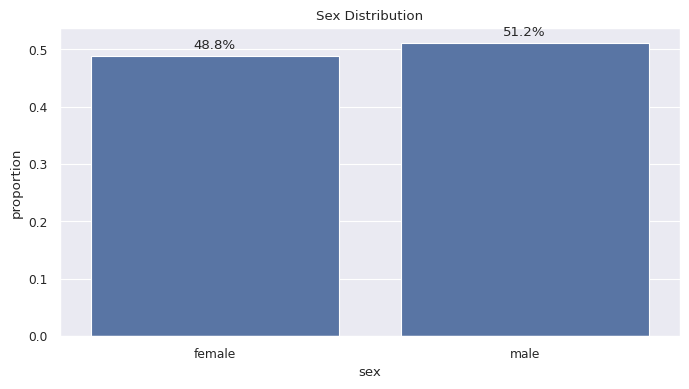

In [7]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_train, x='sex', stat='proportion')
label_pct(ax)
plt.title('Sex Distribution')
plt.savefig('../exports_visualization/viz_sex.png')
plt.show()

Perfectly balanced: 51.2%% male, 48.8% female.

## Smoker

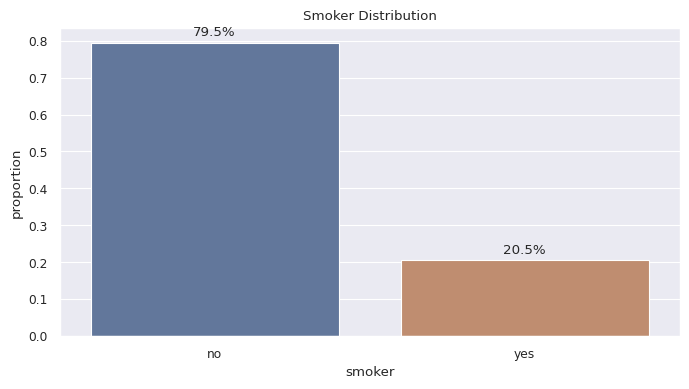

In [8]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_train, x='smoker', hue='smoker',
                   palette=palette, stat='proportion', legend=False)
label_pct(ax)
plt.title('Smoker Distribution')
plt.savefig('../exports_visualization/smoker_distribution.png')
plt.show()

Only 20.5% smokers in the training sample. This minority will turn out to drive most of the cost variance.

## Region

/tmp/ipykernel_52417/716367355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='region', stat='proportion',palette='deep')


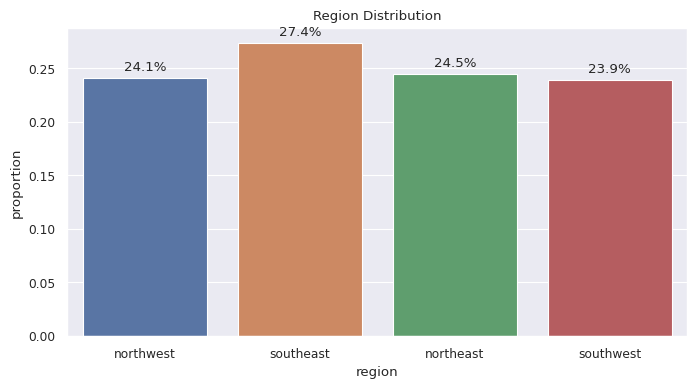

In [9]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_train, x='region', stat='proportion',palette='deep')
label_pct(ax)
plt.title('Region Distribution')
plt.savefig('../exports_visualization/region_distribution.png')
plt.show()

## Age

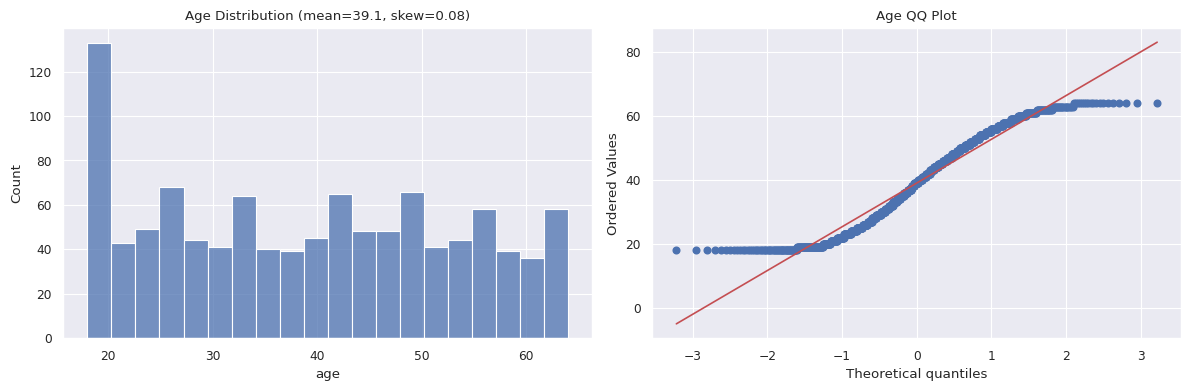

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_train, x='age', bins=20, ax=axes[0])
axes[0].set_title(f'Age Distribution (mean={df_train.age.mean():.1f}, skew={df_train.age.skew():.2f})')
stats.probplot(df_train.age, dist='norm', plot=axes[1])
axes[1].set_title('Age QQ Plot')
plt.tight_layout()
plt.savefig('../exports_visualization/viz_age.png')
plt.show()

Near-uniform distribution. We see that the distribution is not normal due to the bimodal peak at 18.

## BMI

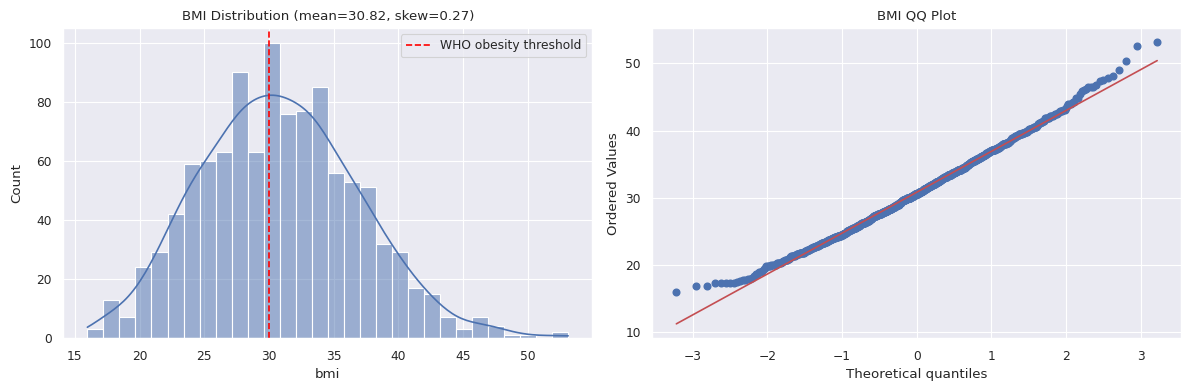

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_train, x='bmi', bins=30, kde=True, ax=axes[0])
axes[0].axvline(30, color='red', linestyle='--', label='WHO obesity threshold')
axes[0].set_title(f'BMI Distribution (mean={df_train.bmi.mean():.2f}, skew={df_train.bmi.skew():.2f})')
axes[0].legend()
stats.probplot(df_train.bmi, dist='norm', plot=axes[1])
axes[1].set_title('BMI QQ Plot')
plt.tight_layout()
plt.savefig('../exports_visualization/viz_bmi.png')
plt.show()

We see that the variable is normal and it is the only one in the dataset. Mean BMI is 30.87 which is at the obesity threshold of the World Health Organization.

## Charges

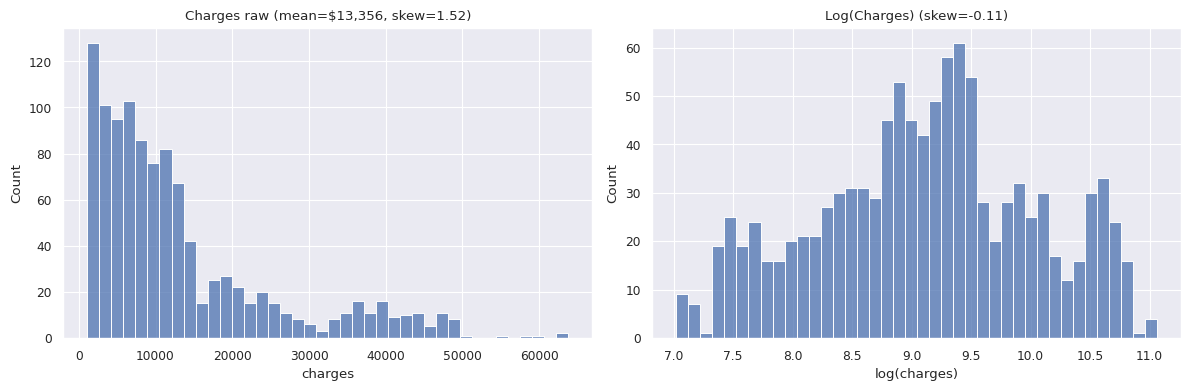

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_train, x='charges', bins=40, ax=axes[0])
axes[0].set_title(f'Charges raw (mean=${df_train.charges.mean():,.0f}, skew={df_train.charges.skew():.2f})')
sns.histplot(x=np.log(df_train.charges), bins=40, ax=axes[1])
axes[1].set(title=f'Log(Charges) (skew={np.log(df_train.charges).skew():.2f})', xlabel='log(charges)')
plt.tight_layout()
plt.savefig('../exports_visualization/viz_charges.png')
plt.show()

We see a strong right skew (skewness 1.52). The log transformation reduces it to near zero (-0.11) which makes the distribution approximately symmetric, what we want before fitting OLS.

## Feature Engineering

In [13]:
def make_features(d):
    d = d.copy()
    d['smoker_num']   = (d['smoker'] == 'yes').astype(int)
    d['sex_num']      = (d['sex'] == 'male').astype(int)
    d['bmi_smoker']   = d['bmi'] * d['smoker_num']
    d['age_smoker']   = d['age'] * d['smoker_num']
    d['bmi_category'] = pd.cut(d['bmi'], bins=[0, 18.5, 25, 30, 100],
    labels=['Under', 'Normal', 'Over', 'Obese'])
    d['age_group']    = pd.cut(d['age'], bins=[17, 30, 45, 60, 65],
    labels=['18-30', '31-45', '46-60', '61-64'])
    d = pd.concat([d, pd.get_dummies(d['region'], prefix='region', drop_first=True)], axis=1)
    return d
df_train = make_features(df_train)
df_test  = make_features(df_test)
FEATURES = ['age', 'sex_num', 'bmi', 'children', 'smoker_num',
'region_northwest', 'region_southeast', 'region_southwest',
'bmi_smoker', 'age_smoker']
X_train = df_train[FEATURES].astype(float)
X_test  = df_test[FEATURES].astype(float)
y_train_log = np.log(df_train['charges'])
y_test_log  = np.log(df_test['charges'])
y_train = df_train['charges'].values
y_test  = df_test['charges'].values
strat   = df_train['smoker_num']
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'bmi_category counts (train): {df_train.bmi_category.value_counts().to_dict()}')
print(f'age_group counts (train): {df_train.age_group.value_counts().to_dict()}')

X_train shape: (1069, 10), X_test shape: (268, 10)
bmi_category counts (train): {'Obese': 577, 'Over': 301, 'Normal': 175, 'Under': 16}
age_group counts (train): {'18-30': 360, '31-45': 319, '46-60': 313, '61-64': 77}


We create two categorical features for EDA stratification (`bmi_category`, `age_group`) and two continuous interaction terms for the OLS model (`bmi_smoker`, `age_smoker`). The interactions let the linear model capture the BMI by smoker pattern visible in the bivariate scatter plot. Without them, the model cannot reach a structure the data clearly contains.



## Bivariate Analysis

Welch t=28.50, ratio=3.73x
Mean smoker $31,938, non smoker $8,568
r charges-smoker=0.778, r charges-bmi=0.180
ANOVA region F=2.31, p=0.0748


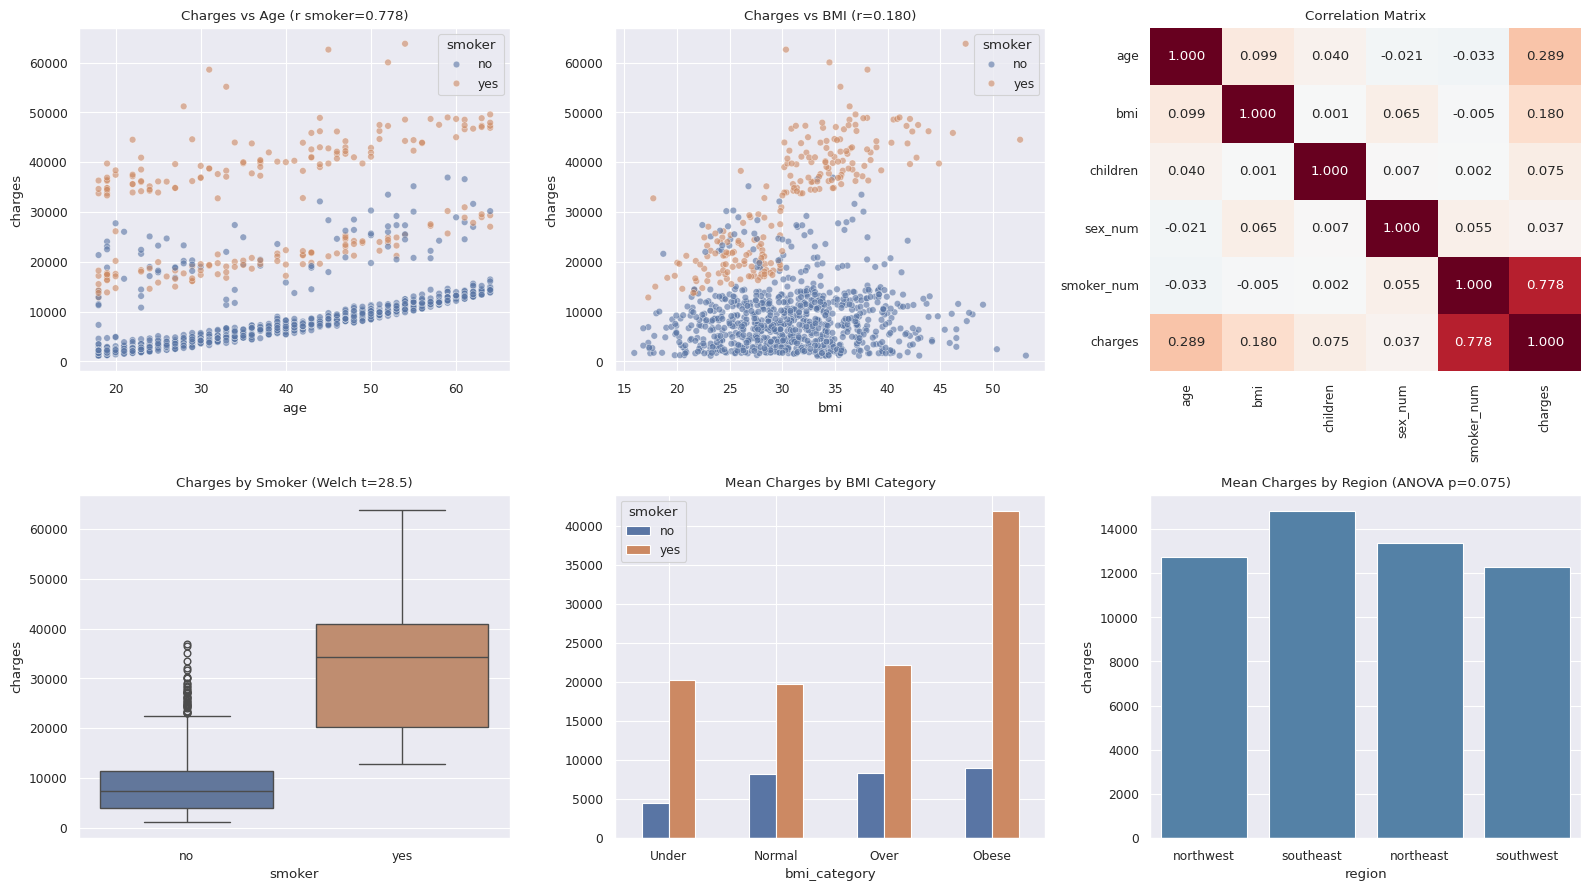

In [14]:
ch_yes = df_train.loc[df_train.smoker == 'yes', 'charges']
ch_no  = df_train.loc[df_train.smoker == 'no',  'charges']
t_stat, t_p = stats.ttest_ind(ch_yes, ch_no, equal_var=False)
r_smoker = stats.pearsonr(df_train.smoker_num, df_train.charges)[0]
r_bmi    = stats.pearsonr(df_train.bmi, df_train.charges)[0]
F_stat, F_p = stats.f_oneway(*[df_train.loc[df_train.region == r, 'charges'].values
for r in df_train.region.unique()])
print(f'Welch t={t_stat:.2f}, ratio={ch_yes.mean()/ch_no.mean():.2f}x')
print(f'Mean smoker ${ch_yes.mean():,.0f}, non smoker ${ch_no.mean():,.0f}')
print(f'r charges-smoker={r_smoker:.3f}, r charges-bmi={r_bmi:.3f}')
print(f'ANOVA region F={F_stat:.2f}, p={F_p:.4f}')
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.scatterplot(data=df_train, x='age', y='charges', hue='smoker',
palette=palette, alpha=0.6, ax=axes[0,0])
axes[0,0].set_title(f'Charges vs Age (r smoker={r_smoker:.3f})')
sns.scatterplot(data=df_train, x='bmi', y='charges', hue='smoker',
palette=palette, alpha=0.6, ax=axes[0,1])
axes[0,1].set_title(f'Charges vs BMI (r={r_bmi:.3f})')
corr_features = ['age', 'bmi', 'children', 'sex_num', 'smoker_num', 'charges']
sns.heatmap(df_train[corr_features].corr(), annot=True, cmap='RdBu_r',
center=0, fmt='.3f', ax=axes[0,2], cbar=False)
axes[0,2].set_title('Correlation Matrix')
sns.boxplot(data=df_train, x='smoker', y='charges', hue='smoker',
palette=palette, ax=axes[1,0], legend=False)
axes[1,0].set_title(f'Charges by Smoker (Welch t={t_stat:.1f})')
piv = df_train.groupby(['bmi_category', 'smoker'], observed=True)['charges'].mean().unstack()
piv.plot(kind='bar', ax=axes[1,1], color=[palette['no'], palette['yes']])
axes[1,1].set_title('Mean Charges by BMI Category')
axes[1,1].tick_params(axis='x', rotation=0)
sns.barplot(data=df_train, x='region', y='charges', ax=axes[1,2],
errorbar=None, color='steelblue')
axes[1,2].set_title(f'Mean Charges by Region (ANOVA p={F_p:.3f})')
plt.tight_layout()
plt.savefig('../exports_visualization/bivariate_analysis.png')
plt.show()

Smoker dominates with r = 0.778 and Welch t = 28.5. Smokers pay 3.73 times more on average ($31,938 vs $8,568). BMI alone has a weak correlation (r = 0.18) because its effect passes through the interaction with smoking, as we see in the stratified bar chart. Region does not reach statistical significance on the training subsample (ANOVA p = 0.075), the visual difference between regions stays small compared to the smoker gap.

## Model 1: Constant Baseline

We start with the no information predictor: every observation gets `mean(charges_train)`. The baseline MAE is the floor any real model must clear.


In [15]:
pred_base = np.full_like(y_test, y_train.mean(), dtype=float)
mae_base  = mean_absolute_error(y_test, pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
r2_base   = r2_score(y_test, pred_base)
print(f'Baseline: R²={r2_base:.4f}, MAE=${mae_base:,.0f}, RMSE=${rmse_base:,.0f}')

Baseline: R²=-0.0010, MAE=$9,081, RMSE=$12,013


## Model 2: OLS on log(charges)

We use ten predictors including the two interactions. Standard errors are HC3 robust because the bivariate scatter plots already show a clear cone of variance: charges spread out much more for smokers than for non smokers, especially at older ages and higher BMI. Dollar scale predictions use Duan's smearing factor to remove the bias from exponentiating log predictions.


In [16]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
ols = sm.OLS(y_train_log, X_train_sm).fit(cov_type='HC3')

pred_ols = np.exp(ols.predict(X_test_sm))
mae_ols  = mean_absolute_error(y_test, pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, pred_ols))
r2_ols   = r2_score(y_test, pred_ols)
r2_ols_log = r2_score(y_test_log, ols.predict(X_test_sm))

print(f'R² train log: {ols.rsquared:.4f}, test log: {r2_ols_log:.4f}, test $: {r2_ols:.4f}')
print(f'MAE=${mae_ols:,.0f}, RMSE=${rmse_ols:,.0f}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = [LinearRegression().fit(X_train.iloc[tr], y_train_log.iloc[tr])
                                  .score(X_train.iloc[va], y_train_log.iloc[va])
             for tr, va in skf.split(X_train, strat)]
print(f'CV R² log: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

duan = np.mean(np.exp(y_train_log - ols.predict(X_train_sm)))
print(f'Duan: {duan:.4f}, MAE with Duan: ${mean_absolute_error(y_test, pred_ols*duan):,.0f} (over corrects, naive exp kept)')

R² train log: 0.8059, test log: 0.8969, test $: 0.8066
MAE=$2,727, RMSE=$5,280
CV R² log: 0.7910 ± 0.1050
Duan: 1.1344, MAE with Duan: $3,687 (over corrects, naive exp kept)


### VIF Check
We check VIFs to verify the multicollinearity expected from including a variable and its interaction in the same design matrix. High VIFs on those terms would not bias predictions, which is our objective here.




In [17]:
print(pd.DataFrame({
    'Variable': FEATURES,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(len(FEATURES))]
}).sort_values('VIF', ascending=False).round(2).to_string(index=False))

        Variable   VIF
      smoker_num 31.64
      bmi_smoker 28.30
             bmi 13.10
      age_smoker 10.61
             age  9.51
region_southeast  2.27
         sex_num  2.04
region_southwest  1.95
region_northwest  1.88
        children  1.84


The interactions and their components show the expected inflation. We keep the specification since it does not threaten predictive validity.


## OLS Results

In [18]:
print(ols.summary().tables[1])

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.1965      0.089     81.221      0.000       7.023       7.370
age                  0.0408      0.001     33.260      0.000       0.038       0.043
sex_num             -0.1035      0.025     -4.102      0.000      -0.153      -0.054
bmi                  0.0007      0.002      0.299      0.765      -0.004       0.005
children             0.1144      0.010     11.482      0.000       0.095       0.134
smoker_num           1.1966      0.127      9.418      0.000       0.948       1.446
region_northwest    -0.0645      0.037     -1.720      0.085      -0.138       0.009
region_southeast    -0.1543      0.038     -4.042      0.000      -0.229      -0.079
region_southwest    -0.1648      0.036     -4.567      0.000      -0.235      -0.094
bmi_smoker           0.0532      0.004     14.141      0.000     

The model explains 80.59% of log(charges) variance and the test set R² is 0.90. `smoker_num` is the dominant predictor

## Standardized Coefficients

         feature  beta_std  abs
      bmi_smoker      0.68 0.68
             age      0.57 0.57
      age_smoker     -0.56 0.56
      smoker_num      0.48 0.48
        children      0.14 0.14
region_southwest     -0.07 0.07
region_southeast     -0.07 0.07
         sex_num     -0.05 0.05
region_northwest     -0.03 0.03
             bmi      0.00 0.00


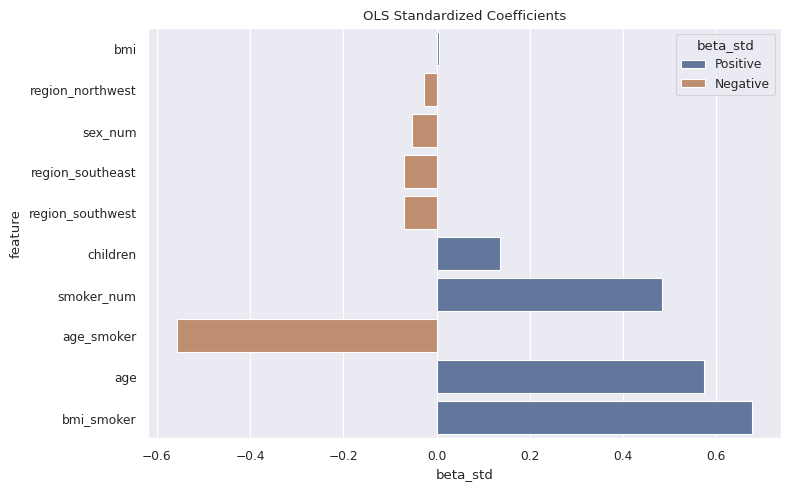

In [19]:
X_train_std = (X_train - X_train.mean()) / X_train.std()
ols_std = sm.OLS(y_train_log, sm.add_constant(X_train_std)).fit(cov_type='HC3')
std_df = pd.DataFrame({'feature': FEATURES, 'beta_std': ols_std.params[1:].values})
std_df['abs'] = std_df['beta_std'].abs()
std_df = std_df.sort_values('abs', ascending=True)
print(std_df.sort_values('abs', ascending=False).round(2).to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=std_df, y='feature', x='beta_std',
            hue=(std_df['beta_std'] >= 0).map({True: 'Positive', False: 'Negative'}),
            palette={'Positive': '#5975a4', 'Negative': '#cc8963'})
plt.title('OLS Standardized Coefficients')
plt.tight_layout()
plt.savefig('../exports_visualization/ols_stdzd_coefficients.png')
plt.show()

del X_train_std, ols_std

We can see bmi_smoker dominates followed by age and smoker_num. This ranking is consistent with Random Forest feature importance.

### Residual Diagnostics



Breusch and Pagan: stat=67.50, p=1.34e-10
Residual skew=2.85, kurt=9.48


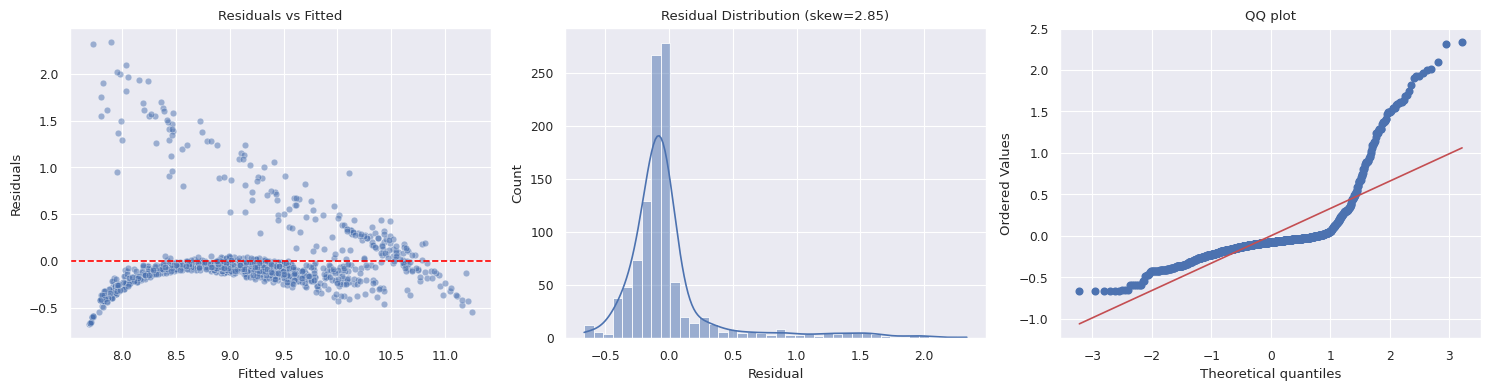

In [20]:
bp_stat, bp_p, _, _ = het_breuschpagan(ols.resid, X_train_sm)
print(f'Breusch and Pagan: stat={bp_stat:.2f}, p={bp_p:.2e}')
print(f'Residual skew={ols.resid.skew():.2f}, kurt={ols.resid.kurt():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x=ols.fittedvalues, y=ols.resid, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Fitted values', ylabel='Residuals', title='Residuals vs Fitted')
sns.histplot(x=ols.resid, bins=40, kde=True, ax=axes[1])
axes[1].set(title=f'Residual Distribution (skew={ols.resid.skew():.2f})', xlabel='Residual')
stats.probplot(ols.resid, dist='norm', plot=axes[2])
axes[2].set_title('QQ plot')
plt.tight_layout()
plt.savefig('../exports_visualization/ols_diagnostics.png')
plt.show()

The Breusch and Pagan test formally confirms what the bivariate scatter plots already suggested: heteroscedasticity is present (statistic 67.5, p near 0). The HC3 standard errors used in fitting absorb the impact. The residual fan pattern and heavy QQ tails reflect the bimodal smoker non smoker cost structure that a single linear equation cannot fully eliminate.


## Model 3: Gamma GLM with Log Link

In [21]:
glm = sm.GLM(y_train, X_train_sm,
             family=sm.families.Gamma(link=sm.families.links.Log())).fit()
pred_glm = glm.predict(X_test_sm)
mae_glm  = mean_absolute_error(y_test, pred_glm)
rmse_glm = np.sqrt(mean_squared_error(y_test, pred_glm))
r2_glm   = r2_score(y_test, pred_glm)
print(f'GLM Gamma: R²={r2_glm:.4f}, MAE=${mae_glm:,.0f}, RMSE=${rmse_glm:,.0f}')

GLM Gamma: R²=0.8147, MAE=$3,100, RMSE=$5,169


The Gamma with log link family is the canonical actuarial specification for cost data that is non negative and right skewed. It models the dollar scale mean directly so no Duan correction is needed, and its multiplicative structure mirrors how insurers actually price risk.


## Model 4: Random Forest
An ensemble of 200 trees on the same features as OLS. Hyperparameters come from a light grid search with stratified 5 fold CV. Interaction terms remain in the design matrix so the comparison with OLS stays fair, even though a tree can discover interactions on its own.

In [22]:
rf_grid = GridSearchCV(
    RandomForestRegressor(n_estimators=200, random_state=seed, n_jobs=-1),
    {'max_depth': [5, 7, 10], 'min_samples_leaf': [3, 5, 10]},
    cv=list(skf.split(X_train, strat)), scoring='r2', n_jobs=-1
).fit(X_train, y_train_log)

rf = rf_grid.best_estimator_
pred_rf = np.exp(rf.predict(X_test))
mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf   = r2_score(y_test, pred_rf)
print(f'Best: {rf_grid.best_params_}, CV R² log: {rf_grid.best_score_:.4f}')
print(f'Test: R²={r2_rf:.4f}, MAE=${mae_rf:,.0f}, RMSE=${rmse_rf:,.0f}')

del rf_grid

Best: {'max_depth': 7, 'min_samples_leaf': 10}, CV R² log: 0.7953
Test: R²=0.9259, MAE=$1,637, RMSE=$3,269


R² 0.93 on test, MAE $1,637. Best parameters: max_depth 7, min_samples_leaf 10.

### Learning Curves

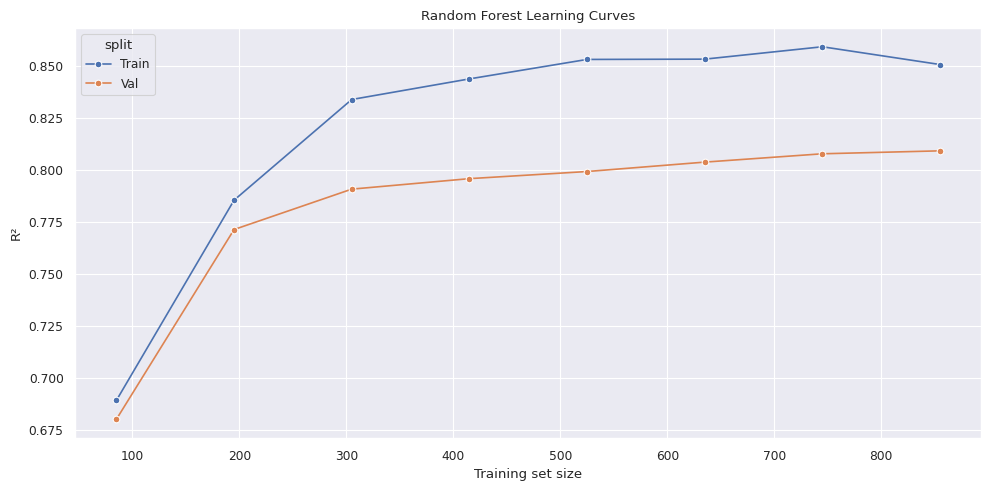

Final train R² 0.8507, val R² 0.8092, gap 0.0415


In [23]:
train_sz, train_sc, val_sc = learning_curve(rf, X_train, y_train_log,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=5, scoring='r2', n_jobs=-1)

lc = pd.DataFrame({
    'size':  np.tile(train_sz, 2),
    'R²':    np.concatenate([train_sc.mean(axis=1), val_sc.mean(axis=1)]),
    'split': ['Train']*len(train_sz) + ['Val']*len(train_sz)
})

plt.figure(figsize=(10, 5))
sns.lineplot(data=lc, x='size', y='R²', hue='split', marker='o', palette='deep')
plt.title('Random Forest Learning Curves')
plt.xlabel('Training set size')
plt.tight_layout()
plt.savefig('../exports_visualization/learning_curves.png')
plt.show()
print(f'Final train R² {train_sc[-1].mean():.4f}, val R² {val_sc[-1].mean():.4f}, gap {train_sc[-1].mean()-val_sc[-1].mean():.4f}')

Train and validation R² converge as the sample grows with a final gap below 0.05. The model generalizes and additional data would yield diminishing returns.

### Permutation Importance

We report permutation importance rather than impurity scores because the default ranking is biased toward continuous variables with many distinct values. The ranking matches the OLS standardized coefficients almost exactly: `bmi_smoker` first, then `age`, then `smoker_num`. This cross model convergence is the strongest evidence we have for the BMI by smoker interaction.



         feature  importance    std
             age      0.6892 0.0571
      bmi_smoker      0.6727 0.0562
        children      0.0664 0.0161
      smoker_num      0.0148 0.0019
      age_smoker      0.0140 0.0014
             bmi      0.0083 0.0020
         sex_num      0.0016 0.0025
region_southeast      0.0015 0.0006
region_southwest      0.0014 0.0006
region_northwest     -0.0003 0.0004


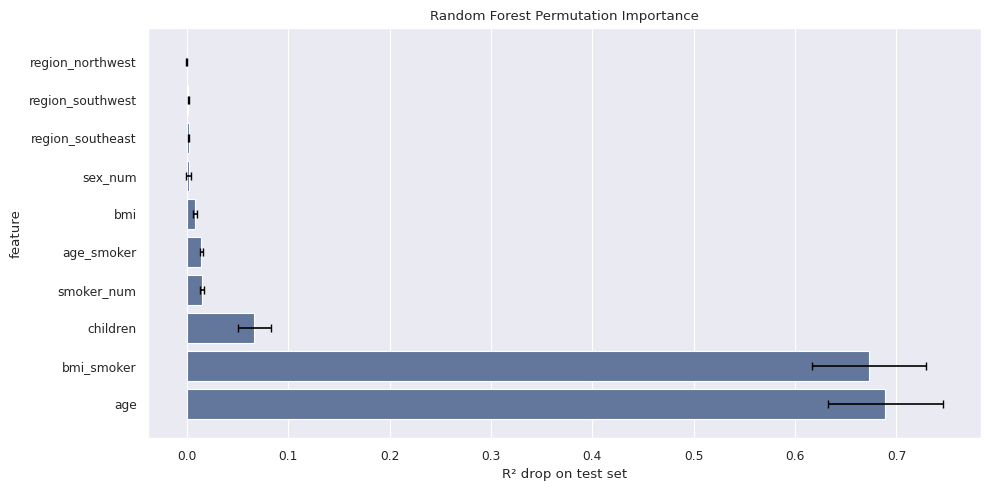

In [24]:
perm = permutation_importance(rf, X_test, y_test_log, n_repeats=20,
                              random_state=seed, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=True)
print(perm_df.sort_values('importance', ascending=False).round(4).to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=perm_df, y='feature', x='importance', color='#5975a4')
plt.errorbar(perm_df['importance'], range(len(perm_df)),
             xerr=perm_df['std'], fmt='none', color='black', capsize=3)
plt.title('Random Forest Permutation Importance')
plt.xlabel('R² drop on test set')
plt.tight_layout()
plt.savefig('../exports_visualization/permutation_importance.png')
plt.show()

del perm

## Model Comparison
We compare all four models on the same test set with dollar scale MAE and RMSE, OLS Duan corrected.


        Model    R²  MAE ($)  RMSE ($)
     Baseline -0.00  9080.77  12012.59
      OLS log  0.81  2726.54   5280.42
    GLM Gamma  0.81  3100.27   5168.72
Random Forest  0.93  1637.06   3269.15


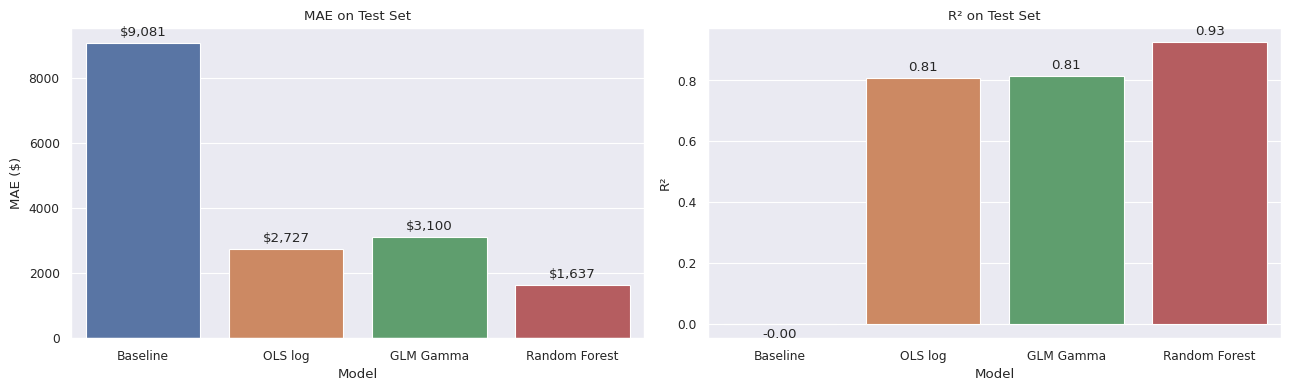

In [25]:
comp = pd.DataFrame({
    'Model':    ['Baseline', 'OLS log', 'GLM Gamma', 'Random Forest'],
    'R²':       [r2_base, r2_ols, r2_glm, r2_rf],
    'MAE ($)':  [mae_base, mae_ols, mae_glm, mae_rf],
    'RMSE ($)': [rmse_base, rmse_ols, rmse_glm, rmse_rf]
})
print(comp.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=comp, x='Model', y='MAE ($)', hue='Model',
            palette='deep', ax=axes[0], legend=False)
for c in axes[0].containers:
    axes[0].bar_label(c, labels=[f'${v.get_height():,.0f}' for v in c], padding=3)
axes[0].set_title('MAE on Test Set')

sns.barplot(data=comp, x='Model', y='R²', hue='Model',
            palette='deep', ax=axes[1], legend=False)
for c in axes[1].containers:
    axes[1].bar_label(c, labels=[f'{v.get_height():.2f}' for v in c], padding=3)
axes[1].set_title('R² on Test Set')
plt.tight_layout()
plt.savefig('../exports_visualization/model_comparison.png')
plt.show()

Random Forest achieves the lowest error on both MAE and RMSE, well ahead of the linear models. OLS log and Gamma GLM are essentially tied at R² 0.81, with OLS slightly better on MAE ($2,727 vs $3,100) and Gamma slightly better on RMSE ($5,169 vs $5,280), confirming that the two specifications are equivalent in practice on this dataset. All three models destroy the constant baseline that sits at $9,081 MAE.

## Paired Bootstrap Test

Δ MAE (OLS-RF) = $1,089
95% CI = [$702, $1,513]
Significant at 5%: True


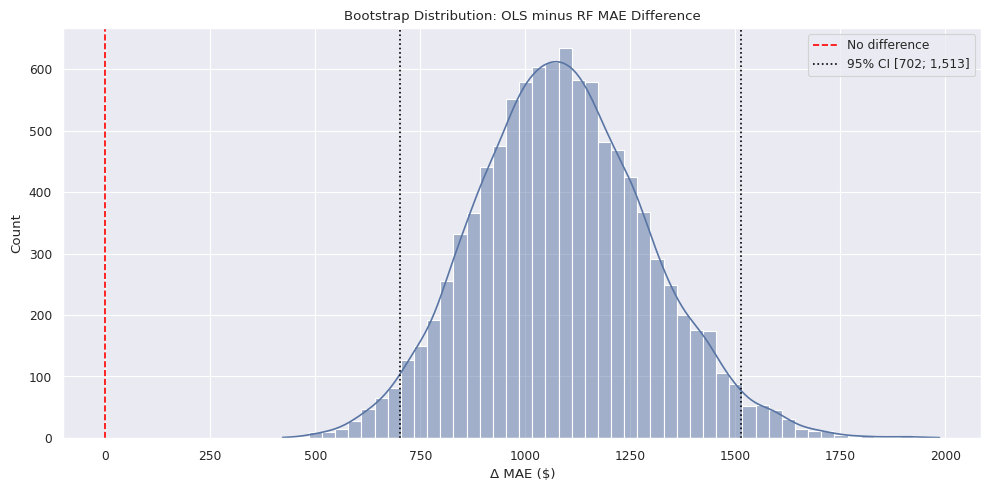

In [26]:
err_ols = np.abs(y_test - pred_ols)
err_rf  = np.abs(y_test - pred_rf)
n = len(y_test)
diffs = np.empty(10000)
rng = np.random.default_rng(seed)
for i in range(10000):
    idx = rng.integers(0, n, size=n)
    diffs[i] = err_ols[idx].mean() - err_rf[idx].mean()
ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
print(f'Δ MAE (OLS-RF) = ${diffs.mean():,.0f}')
print(f'95% CI = [${ci_lo:,.0f}, ${ci_hi:,.0f}]')
print(f'Significant at 5%: {(ci_lo > 0) or (ci_hi < 0)}')

plt.figure(figsize=(10, 5))
sns.histplot(x=diffs, bins=50, kde=True, color='#5975a4')
plt.axvline(0, color='red', linestyle='--', label='No difference')
plt.axvline(ci_lo, color='black', linestyle=':', label=f'95% CI [{ci_lo:,.0f}; {ci_hi:,.0f}]')
plt.axvline(ci_hi, color='black', linestyle=':')
plt.title('Bootstrap Distribution: OLS minus RF MAE Difference')
plt.xlabel('Δ MAE ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../exports_visualization/bootstrap_distribution.png')
plt.show()

del diffs, err_ols, err_rf

10,000 paired resamples of the test set absolute errors. The 95% CI on the OLS minus Random Forest MAE difference tells us if the Random Forest edge is robust or sampling noise.

## Risk Profiles Segmentation
We segment beneficiaries into five tiers using the quintile boundaries of the OLS predictions on the training set. The boundaries are frozen and applied to the test set. This is monotone by construction, grounded in a fitted model rather than expert weights, and validated on data the model has not seen.

Quintile bounds: [4050.0, 7159.0, 11114.0, 17946.0]
          count     mean
tier                    
Minimal      52   2732.0
Low          55   5367.0
Moderate     51  10239.0
High         55  13500.0
Maximum      55  32269.0
Ratio max/min: 11.8x


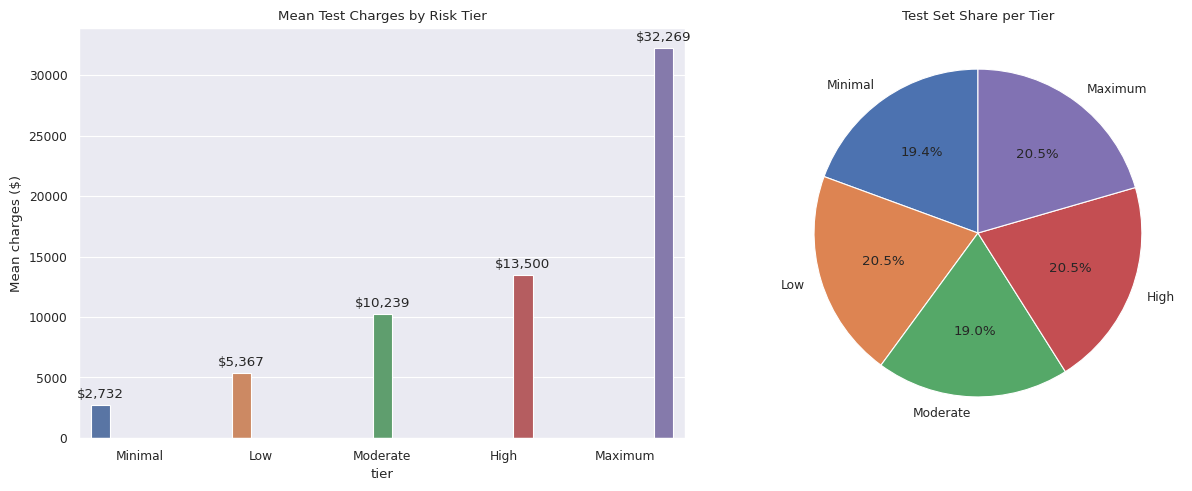

In [27]:
pred_ols_train = np.exp(ols.predict(X_train_sm))
bounds = np.percentile(pred_ols_train, [20, 40, 60, 80])
print(f'Quintile bounds: {bounds.round(0).tolist()}')

tiers = pd.cut(pred_ols, bins=[0.0]+list(bounds)+[np.inf],
               labels=['Minimal','Low','Moderate','High','Maximum'])
summary = pd.DataFrame({'tier': tiers, 'charges': y_test}) \
            .groupby('tier', observed=True)['charges'] \
            .agg(['count', 'mean']).round(0)
print(summary.to_string())
ratio = summary['mean'].iloc[-1] / summary['mean'].iloc[0]
share = summary['count'] / summary['count'].sum() * 100
print(f'Ratio max/min: {ratio:.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax_bar = sns.barplot(x=summary.index, y=summary['mean'], hue=summary.index,
                     palette='deep', ax=axes[0], legend=False)
for c in ax_bar.containers:
    ax_bar.bar_label(c, labels=[f'${v.get_height():,.0f}' for v in c], padding=3)
axes[0].set(title='Mean Test Charges by Risk Tier', ylabel='Mean charges ($)')

axes[1].pie(share, labels=share.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('deep', n_colors=5))
axes[1].set_title('Test Set Share per Tier')
plt.tight_layout()
plt.savefig('../exports_visualization/risk_profile.png')
plt.show()


del tiers, pred_ols_train

The ratio between the maximum and minimum tier mean charges is about 11 times, which supports a five tier pricing structure. The highest risk profile represents roughly 20% of the test set.


##  Conclusion
Five demographic features plus a smoker indicator explain about 90% of test set variance in log(charges) when the BMI by smoker interaction is included. The convergence of OLS, Gamma GLM and Random Forest on the same dominant predictors is the strongest claim of the study. The five tier segmentation delivers an 11.8x cost ratio between top and bottom tiers.